## Descripción del problema de negocio

El lenguaje de señas es la principal forma de comunicación para la comunidad sorda. Sin embargo, la accesibilidad a servicios básicos (salud, educación, atención al cliente) sigue siendo un desafío debido a la escasez de intérpretes y de herramientas tecnológicas de apoyo. Este proyecto explora el uso de técnicas de aprendizaje profundo, específicamente un Perceptrón Multicapa (MLP), para reconocer letras individuales del alfabeto de señas, con el objetivo de sentar las bases para futuros sistemas de traducción automática de señas.

## Variante

En lugar de trabajar con la totalidad del alfabeto (24 clases), este proyecto se enfoca en un subconjunto de **6 letras que presentan una alta similitud visual**: **A, E, M, N, S y T**. Esta selección no es arbitraria; estas letras fueron escogidas porque:
- Sus configuraciones de dedos son fácilmente confundibles entre sí (ej. M, N y S utilizan el puño con variaciones de los dedos).
- Su clasificación representa un desafío significativo para un modelo MLP, al no poder capturar relaciones espaciales sutiles.
- Evaluar el desempeño en este subconjunto permite diagnosticar de forma más clara las limitaciones de los MLP en tareas de visión y justifica la necesidad de arquitecturas más avanzadas (como las CNN) en trabajos futuros.

## Objetivos del proyecto

1.  **Objetivo general:**
    -   Evaluar la viabilidad de un Perceptrón Multicapa para clasificar un conjunto de letras del lenguaje de señas visualmente similares.

2.  **Objetivos específicos:**
    -   Seleccionar y preprocesar las 6 letras del dataset Sign Language MNIST.
    -   Implementar y comparar diferentes arquitecturas MLP (variando capas y neuronas) para determinar la complejidad adecuada al problema.
    -   Optimizar hiperparámetros (optimizador, learning rate, batch size) para maximizar el rendimiento.
    -   Analizar en profundidad las confusiones entre las clases M, N y S, identificando las principales fuentes de error.
    -   Reflexionar sobre las limitaciones del MLP y proponer mejoras (aumento de datos, arquitecturas convolucionales).

## KPIs (Indicadores Clave de Desempeño)

1.  **Precisión global (Accuracy):** Porcentaje de señas clasificadas correctamente sobre el total. Es la métrica principal del rendimiento general.
2.  **F1-Score por clase:** Especialmente crítico para las clases M, N y S, donde se espera un desempeño más bajo. Este indicador permite evaluar el equilibrio entre precisión y exhaustividad para las clases más difíciles.
3.  **Tasa de confusión entre pares (M-S, M-N, N-A):** Análisis de los errores sistemáticos más frecuentes. Este indicador cualitativo es fundamental para entender las limitaciones del modelo y guiar la elección de futuras arquitecturas o técnicas de preprocesamiento.

## Comprensión y exploración del conjunto de datos

In [ ]:
!pip install kagglehub -q

In [ ]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

Se importan las librerias necesarias para realizar el desarrollo del modelo Deep learning

In [ ]:
path = kagglehub.dataset_download("datamunge/sign-language-mnist")
train = pd.read_csv(f"{path}/sign_mnist_train.csv")
test = pd.read_csv(f"{path}/sign_mnist_test.csv")



x_train = train.drop('label', axis=1).values
y_train = train['label'].values

x_test = test.drop('label', axis=1).values
y_test = test['label'].values

letras_similares = [0, 4, 12, 13, 18, 19]

mask_train = np.isin(y_train, letras_similares)
mask_test = np.isin(y_test, letras_similares)

x_train_filtrado = x_train[mask_train]
y_train_filtrado = y_train[mask_train]

x_test_filtrado = x_test[mask_test]
y_test_filtrado = y_test[mask_test]

mapeo_clases = {clase_orig: idx for idx, clase_orig in enumerate(letras_similares)}
etiquetas_nombre = {0: 'A', 4: 'E', 12: 'M', 13: 'N', 18: 'S', 19: 'T'}

y_train_mapped = np.array([mapeo_clases[val] for val in y_train_filtrado])
y_test_mapped = np.array([mapeo_clases[val] for val in y_test_filtrado])

100%|██████████| 62.6M/62.6M [00:02<00:00, 31.1MB/s]

Extracting files...


In [ ]:
print(x_train.shape)
print(y_train.shape)

(27455, 784)
(27455,)


El código inicial realiza la lectura del dataset de entrenamiento y prueba, separando las variables predictoras (x_train, x_test) de las etiquetas a predecir (y_train, y_test).
Dimensiones originales: La salida nos dice que hay un total de 27,455 muestras de entrenamiento, donde cada instancia cuenta con 784 características(pixeles)  Teniendo en cuenta la naturaleza de los datos, cada fila representa una imagen aplanada de 28x28 pixeles en escala de grises del lenguaje de señas, donde cada columna almacena un valor de intensidad de píxel entre 0 y 255

Dado que las clases originales del dataset completo no se encuentran indexadas de forma secuencial algo que resulta necesario para el uso de funciones de pérdida como la Categorical Cross-Entropy o capas de salida con activación Softmax en redes neuronales, el código ejecuta dos procesos importantes:

Filtro(np.isin): Se filtran tanto el conjunto de entrenamiento como el de prueba para conservar unicamente los registros asociados a las 6 letras seleccionadas, reduciendo el espacio de busqueda a algo mas manejable para una arquitectura perceptrón multicapa

Mapeo (mapeo_clases): Tambien se implementa un diccionario de conversión que reasigna las etiquetas originales dispersas a un rango continuo y ordenado de índices de 0 a 5 (del 1 al 6 correspondientemente). Esto garantiza que la capa de salida de la red neuronal interprete correctamente las clases sin generar errores en los indices durante el cálculo del gradiente y la perdida

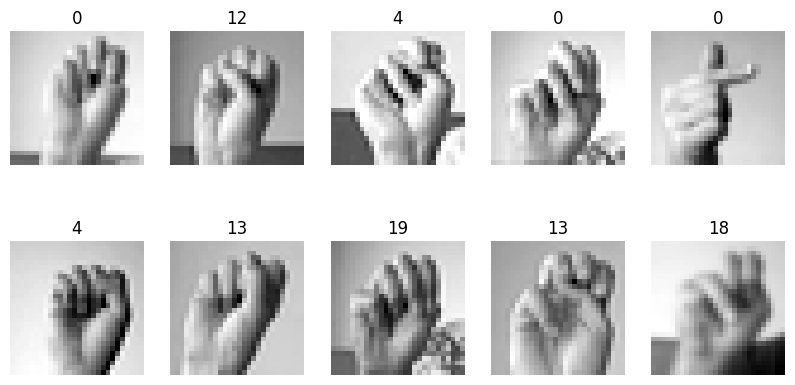

In [ ]:
fig, ax = plt.subplots(2,5,figsize = (10,5))
for i,a in enumerate(ax.ravel()):
  a.imshow(x_train_filtrado[i].reshape(28, 28), cmap="gray")
  a.set_title(y_test_filtrado[i])
  a.axis("off")
plt.show()

utilizando matplotlib para visualizar diez ejemplos representativos del conjunto de datos donde se realiza la remodelacion de vectores a matrices (28x28)

Cada instancia almacenada originalmente como un vector plano de 784 características es convertida nuevamente a su matriz espacial original mediante .reshape(28, 28) para permitir su renderizado como imagen en escala de grises

A través de la visualización nos permiten apreciar tanto las características estructurales del dataset Sign MNIST, destacando la variabilidad en la postura de la mano, la iluminación y la cercanía al encuadre, lo cual nos da entender la complejidad del problema de clasificación que a de resolver el modelo de Perceptrón Multicapa

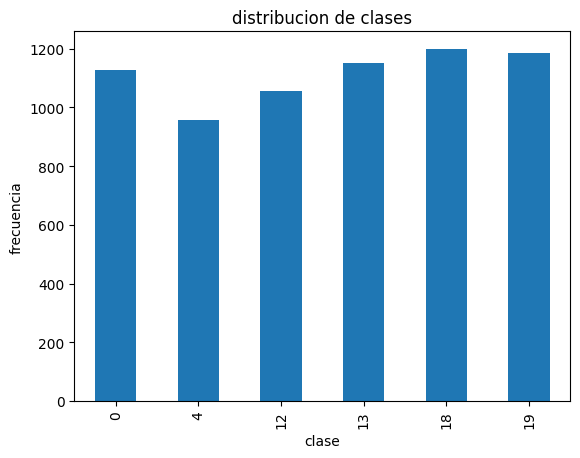

In [ ]:
pd.Series(y_train_filtrado).value_counts().sort_index().plot(kind="bar")
plt.title("distribucion de clases")
plt.xlabel("clase")
plt.ylabel("frecuencia")
plt.show()

En esta parte del codigo visualizamos la frecuencia de cada etiqueta o clase en el conjunto de entrenamiento filtrado, ordenandolo secuencialmente para mejor entendimiento

El gráfico de barras muestra las frecuencias correspondientes a las seis clases analizadas (0, 4, 12, 13, 18 y 19). Se observa una distribución relativamente equilibrada entre las categorías, donde cada una ronda aproximadamente entre las 950 y 1,200 muestras de entrenamiento

Este equilibrio es un factor a tomar en cuenta para el aprendizaje de un Perceptrón Multicapa (MLP). Al no existir un desbalance severo de clases (clases mayoritarias que dominen el entrenamiento frente a otras con muy pocos registros), se reduce el riesgo de que el modelo sufra de sesgos predictivos importantes hacia una categoría en particular, permitiendo que las métricas globales como el Accuracy reflejen el desempeño real de la red neuronal

## preparacion de datos

In [ ]:
x_train = x_train_filtrado / 255.0
x_test = x_test_filtrado / 255.0


y_train_cat = to_categorical(y_train_mapped, num_classes=6)
y_test_cat = to_categorical(y_test_mapped, num_classes=6)

x_tr, x_val, y_tr, y_val = train_test_split(
    x_train,
    y_train_cat,
    test_size=0.2,
    random_state=2026,
    stratify=y_train_cat
)

In [ ]:
x_train.shape

(6674, 784)

Normalización de píxeles: Dado que los valores originales de las imágenes se encuentran en un rango de 0 a 255 en la escala de grises, dividir estas matrices entre 255 escala todos los valores a un rango entre 0.0 y 1.0(decimales u porcentaje)
Esto es necesario realizarlo en redes neuronales para evitar gradientes desbalanceados y acelerar la convergencia del algoritmo de optimización durante los entrenamiento

Codificación One-Hot Encoding: Las etiquetas enteras mapeadas  se transforman en vectores de longitud 6 mediante la función to_categorical. es decir, si una etiqueta representa la clase 2, su representación categórica será un vector del tipo de tipo binario (0, 0, 1, 0, 0, 0). Esto es un requisito obligatorio para que la capa de salida de la red (con activación Softmax) pueda calcular el error correctamente

Partición de validación (train_test_split): El conjunto de entrenamiento se subdivide en dos subconjuntos: uno para entrenar (train, 80%) y otro para validar el desempeño del modelo epoca a epoca (validation, 20%) random_state fijaria una semilla "aleatoria" para garantizar la trazabilidad y reproducibilidad exacta de los datos divididos en futuras ejecuciones

stratify=y_train_cat: Nos asegura que la proporción de cada una de las 6 clases sea exactamente la misma tanto en el set de entrenamiento como en el de validación, evitando sesgos por desbalance aleatorio.
La dimension resulante de esto el conjunto de entrenamiento procesado cuenta con 6,674 muestras, cada una compuesta por un vector aplanado de 784 características (píxeles)

## Modelo Base

In [ ]:
def graficar_historial(history, titulo):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))


    ax1.plot(history.history['loss'], label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Val Loss')
    ax1.set_title(f'Pérdida - {titulo}')
    ax1.set_xlabel('Época')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)


    ax2.plot(history.history['accuracy'], label='Train Acc')
    ax2.plot(history.history['val_accuracy'], label='Val Acc')
    ax2.set_title(f'Precisión - {titulo}')
    ax2.set_xlabel('Época')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
def evaluar_modelo_completo(model, history, x_test, y_test_cat, titulo):
    graficar_historial(history, titulo)

    y_pred_probs = model.predict(x_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test_cat, axis=1)
    test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)

    print(f"\n================ RESUMEN DE EVALUACIÓN: {titulo} ================")
    print(f"Test Accuracy:        {test_acc * 100:.2f}%")
    print(f"Test Loss:            {test_loss:.4f}")
    print(f"=================================================================\n")


    nombres_letras = ['A', 'E', 'M', 'N', 'S', 'T']
    print(classification_report(y_true, y_pred, target_names=nombres_letras))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=nombres_letras, yticklabels=nombres_letras)
    plt.xlabel('Predicción del Modelo')
    plt.ylabel('Clase Real')
    plt.title(f'Matriz de Confusión - {titulo}')
    plt.show()

Realizamos 2 funciones especificas que nos permitiran automatizar los procesos de registro de modelos y ver su desempeño por un lado:

La función graficar_historial automatiza el registro y la representación gráfica del proceso de aprendizaje de la red neuronal a lo largo de las epocas, nos permite graficar de forma simultánea la evolución de la función de pérdida tanto para el conjunto de entrenamiento, como para el de validación. Permite identificar la convergencia del optimizador y detectar de manera temprana signos de sobreajuste (overfitting), el cual se manifiesta cuando la pérdida de entrenamiento sigue disminuyendo mientras la de validación comienza a incrementarse
Luego esta el grafico de Precisión, que compara la precisión obtenida en los datos de entrenamiento frente a los de validación en cada una de las epocas. facilitando la visualización de la estabilidad del aprendizaje y el porcentaje maximo de acierto alcanzado por el modelo MLP

Luego tenemos la funcion para evaluar los desempeños de los distintos modelos de forma automatiza y eficiente:

La función evaluar_modelo_completo encapsula la fase de prueba sobre los datos, calculando y reportando las métricas e interpretaciones gráficas

1. Para la inferencia y conversión de Probabilidades, obtenemos un lista de probabilidades para cada una de las 6 clases de salida calculando cada uno de sus metricas individualmente

    Tambien convierte las probabilidades de la capa Softmax (tanto en las predicciones como en las etiquetas categoricas reales) de vuelta a indices enteros o sus etiquetas reales. Esto permite alinear las predicciones de la red con las etiquetas verdaderas para el calculo de metricas vectorizadas

2. Métricas Globales (Accuracy y Loss de Prueba): Calculamos de forma independiente la pérdida final (Test Loss) y la precisión global (Test Accuracy) del modelo sobre el conjunto de pruebas no visto. Dandonos un valor porcentual para saber la efectividad general del modelo para reconocer correctamente las señas de las letras A, E, M, N, S y T

3. Para el reporte de metricas, utilizamos una lista con los nombres reales de las clases (['A', 'E', 'M', 'N', 'S', 'T']) para calcular metricas avanzadas por categoría ya sea tanto la Precision (Precisión) que es la proporción de predicciones positivas verdaderas frente al total de predicciones positivas realizadas para cada seña, midiendo cuántos falsos positivos genera el modelo

    Tambien calculamos el Recall que mide la capacidad de la red para identificar correctamente todas las instancias reales de cada clase, cuantificando los falsos negativos

    Y por ultimo el F1-Score que calcula la media entre Precision y Recall, entregando una metrica equilibrada fundamental cuando se analizan clases que comparten similitudes visuales complejas dentro de las imagenes de señas

4. Y por ultimo para el analisis generamos una matriz de confusión visual en formato de mapa de calor utilizando una paleta que nos permite identificar de manera grafica que letras especificas generan mayor nivel de confusion en el modelo debido a la similitud que estan puedan tener, logrando asi un analisis critico de errores y limitaciones de la red neuronal en el procesamiento de estas imagenes

In [ ]:


model = Sequential([
    Flatten(input_shape = (784,)),
    Dense(32, activation = "relu"),
    Dense(6, activation = "softmax"),
])
model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,318 (98.90 KB)

 Trainable params: 25,318 (98.90 KB)

 Non-trainable params: 0 (0.00 B)

En esta parte del codigo el modelo se construye utilizando una arquitectura secuencial (Sequential) en Keras, estructurada en 3 capas importantes:

1. Capa de Entrada (Flatten): Configurada con el valor de 784, actua como interfaz de entrada recibiendo los vectores de 784 características (los píxeles normalizados de las imágenes de 28x28)

2. Capa Oculta (Dense): Configurada con 32 neuronas con funcion de activacion de ReLu 32 neuronas con función de activación ReLU, esta capa es la encargada de extraer patrones de los píxeles de la mano de los datos. Se selecciono la función ReLU porque previene el problema del desvanecimiento del gradiente y permite un aprendizaje eficiente al anular las activaciones negativas o valores negativos.  

3. Capa de Salida (Dense): Configurada con 6 neuronas con función de activación Softmax.  Se configuran exactamente 6 neuronas para coincidir con las 6 clases de señas analizadas(A, E, M, N, S, T).
La función de activación Softmax convierte los valores continuos resultantes en una distribución de probabilidades normalizadas que suman 1.0 (0-100%), facilitando la selección de la clase ganadora

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)
model.compile(
    optimizer = "adam",
    loss = "categorical_crossentropy",
    metrics = ["accuracy"]
)

history = model.fit(
    x=x_tr,
    y=y_tr,
    epochs=50,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=[early_stop]
)

Epoch 1/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3311 - loss: 1.6948 - val_accuracy: 0.4734 - val_loss: 1.5355
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4926 - loss: 1.4250 - val_accuracy: 0.5191 - val_loss: 1.3059
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5750 - loss: 1.2168 - val_accuracy: 0.6442 - val_loss: 1.1354
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6282 - loss: 1.0787 - val_accuracy: 0.6187 - val_loss: 1.0285
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6662 - loss: 0.9651 - val_accuracy: 0.6712 - val_loss: 0.9277
Epoch 6/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7007 - loss: 0.8747 - val_accuracy: 0.7071 - val_loss: 0.8264
Epoch 7/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7295 - loss: 0.7954 - val_accuracy: 0.7356 - val_loss: 0.7685
Epoch 8/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7559 - loss: 0.7306 - val_accuracy: 0.7581 - val_loss:

El proceso de entrenamiento se ejecutó configurando los hiperparámetros de optimización y convergencia necesarios para asegurar un aprendizaje estable del Perceptrón Multicapa.

Hicimos uso de Adam, seleccionado por su capacidad de ajustar dinámicamente la tasa de aprendizaje para cada parámetro, dirigiéndose de una manera más rápida y eficiente hacia el error mínimo.
Como función de pérdida seleccionamos categorical_crossentropy, ideal para problemas de clasificación multiclase con etiquetas en formato One-Hot Encoding.

Por otro lado, como métricas de desempeño utilizamos el accuracy (precisión), para medir el porcentaje de muestras clasificadas correctamente por época.Como hiperparámetros, asegurando la estabilidad y evitando costos computacionales innecesarios, se estableció un límite de 50 épocas con un tamaño de lote (batch_size) de 64 muestras, incorporando además un mecanismo de parada temprana (EarlyStopping) enfocado en la pérdida de validación, con una paciencia de 10 épocas y la instrucción de retener los pesos óptimos del modelo.

Durante la ejecución se evidenció un progreso sólido y continuo: el error de entrenamiento descendió de forma constante desde $1.6948$ hasta $0.0578$, mientras que la pérdida de validación acompañó de la mano al error, decreciendo desde $1.5355$ hasta $0.0576$ en la época 50. Asimismo, el modelo partió con un desempeño inicial del $33.11\%$ de precisión en entrenamiento y del $47.34\%$ en validación, superando el $90\%$ de exactitud alrededor de la época 17 y estabilizándose de forma sobresaliente en las etapas finales.

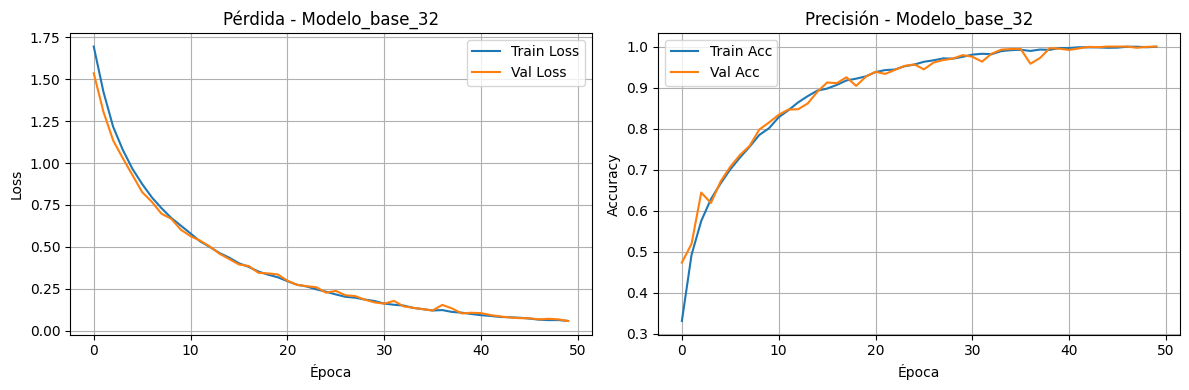


================ RESUMEN DE EVALUACIÓN: Modelo_base_32 ================
Test Accuracy:        79.58%
Test Loss:            0.6764

              precision    recall  f1-score   support

           A       0.86      1.00      0.92       331
           E       0.91      0.87      0.89       498
           M       0.80      0.65      0.72       394
           N       0.70      0.66      0.68       291
           S       0.50      0.57      0.53       246
           T       0.90      1.00      0.95       248

    accuracy                           0.80      2008
   macro avg       0.78      0.79      0.78      2008
weighted avg       0.80      0.80      0.79      2008



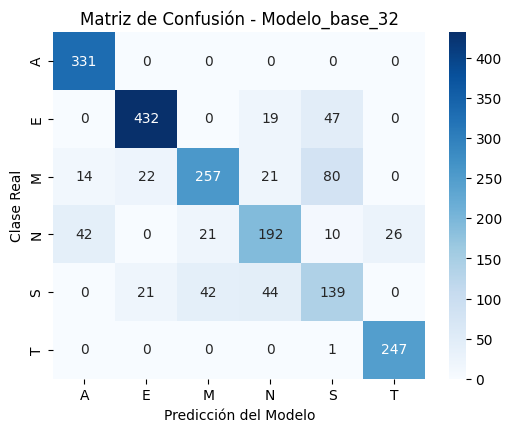

In [ ]:
evaluar_modelo_completo(model, history, x_test, y_test_cat, "Modelo_base_32")

La evaluación del modelo base sobre el conjunto de pruebas arrojó un Test Accuracy de 79.58% y una pérdida global (Test Loss) de 0.6764, validando la capacidad predictiva general de la red, pero evidenciando limitaciones al clasificar señas con alta similitud.

El desglose por categoría revela un rendimiento evidente entre las distintas letras del lenguaje de señas: clases con alto desempeño (A, E, T) presentan los mejores indicadores, destacando la letra A con un recall de 1.00 (100% de las muestras reales detectadas con éxito) y la letra T con una precisión del 0.90 (y un recall perfecto de 1.00). Esto indica que estas señas poseen características más diferenciadas para el modelo. Por otro lado, las clases con bajo desempeño son las letras M, N y S, que concentran las mayores dificultades del modelo. La letra S registra la precisión más baja con un 0.50 y un recall de 0.57, mientras que la letra M presenta un recall reducido de 0.65, reflejando que una gran cantidad de instancias reales de estas clases no logran ser identificadas correctamente por el modelo.

Errores y Matriz de Confusión. La matriz de confusión nos ayuda a auditar de forma precisa los aciertos y las confusiones críticas cometidas por la red:

La confusión principal se encuentra entre M, N y S, debido a la similitud física de las posiciones de los dedos en el lenguaje de señas. De un total de 394 muestras reales de la clase M, el modelo confunde erróneamente 80 instancias con la letra S y 21 con la letra N. De igual forma, 42 muestras de la clase S son clasificadas incorrectamente como M y 44 como N.

Este error se evidencia también en la letra N, donde presenta dispersión hacia la clase A (42 confusiones) y hacia la clase M (21 confusiones), lo que demuestra que las capas densas del MLP sufren para distinguir variaciones sutiles de orientación o iluminación en los píxeles.

Estos resultados nos dan indicios de las limitaciones del uso de un Perceptrón Multicapa para tareas de visión:

Por un lado, al aplanar la imagen a un vector de una sola dimensión de 784 características (Flatten), la red pierde las dimensiones de la estructura original y la correlación entre los píxeles.

Por lo que resulta sensible a las posiciones y formas; el modelo depende exclusivamente de combinaciones lineales de intensidades de píxeles globales, lo que dificulta distinguir patrones locales cuando una mano presenta ligeras rotaciones o variaciones de perspectiva, explicando las confusiones cruzadas observadas en la matriz.

In [ ]:
model_64 = Sequential([
    Flatten(input_shape = (784,)),
    Dense(64, activation = "relu"),
    Dense(32, activation = "relu"),
    Dense(6, activation = "softmax"),
])
model_64.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,518 (205.15 KB)

 Trainable params: 52,518 (205.15 KB)

 Non-trainable params: 0 (0.00 B)

El nuevo modelo implementa una capa oculta extra a diferencia de su anterior modelo:

1. Capa de Entrada (Flatten): Capa de Entrada (Flatten): Configurada con el valor de 784, actua como interfaz de entrada recibiendo los vectores de 784 características (los píxeles normalizados de las imágenes de 28x28)

2. Primera Capa Oculta (Dense):Configurada con 64 neuronas y función de activación ReLU. Su propósito es expandir el espacio de representación inicial para capturar una mayor cantidad de patrones espaciales complejos y combinaciones de píxeles de las señas

3. Segunda Capa Oculta (Dense):Configurada con 32 neuronas y función de activación ReLU. Actúa como una capa de abstracción intermedia que comprime y refina las características extraídas por la capa anterior antes de enviarlas a la clasificación final

4. Capa de Salida (Dense):Configurada con 6 neuronas y activación Softmax, entregando la distribución de probabilidad para las seis clases del problema (A, E, M, N, S, T)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

model_64.compile(
    optimizer = "adam",
    loss = "categorical_crossentropy",
    metrics = ["accuracy"]
)

history_64 = model_64.fit(
    x=x_tr,
    y=y_tr,
    epochs=50,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=[early_stop]
)

Epoch 1/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3875 - loss: 1.5556 - val_accuracy: 0.5326 - val_loss: 1.3097
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5797 - loss: 1.1661 - val_accuracy: 0.6285 - val_loss: 1.0150
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6735 - loss: 0.9227 - val_accuracy: 0.7191 - val_loss: 0.8148
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7398 - loss: 0.7431 - val_accuracy: 0.7251 - val_loss: 0.7078
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7887 - loss: 0.6173 - val_accuracy: 0.7094 - val_loss: 0.6872
Epoch 6/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8088 - loss: 0.5455 - val_accuracy: 0.7573 - val_loss: 0.5813
Epoch 7/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8552 - loss: 0.4617 - val_accuracy: 0.8255 - val_loss: 0.4499
Epoch 8/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8822 - loss: 0.3870 - val_accuracy: 0.8300 - val_loss:

El proceso de entrenamiento del modelo con dos capas ocultas (model_64) completó las 50 épocas establecidas, mostrando una capacidad de aprendizaje mayor y una convergencia mucho más rápida en comparación con el modelo base de 32.El modelo logró reducir la pérdida de entrenamiento de forma drástica desde 1.5556 hasta un valor cercano a cero de 0.0036 en la época 50, alcanzando una precisión perfecta en las últimas épocas del conjunto de entrenamiento.Por otra parte, la pérdida de validación (val_loss) descendió de manera sostenida hasta registrar un mínimo de 0.0040 en la época 49 (y 0.0051 en la última época), mientras que la precisión de validación (val_accuracy) escaló hasta el 100% (1.0000), reflejando que la arquitectura con capas de 64 y 32 neuronas logra capturar de manera muy efectiva los patrones de las señas (al menos dentro del contexto de datos de entrenamiento) sin activar la parada temprana.

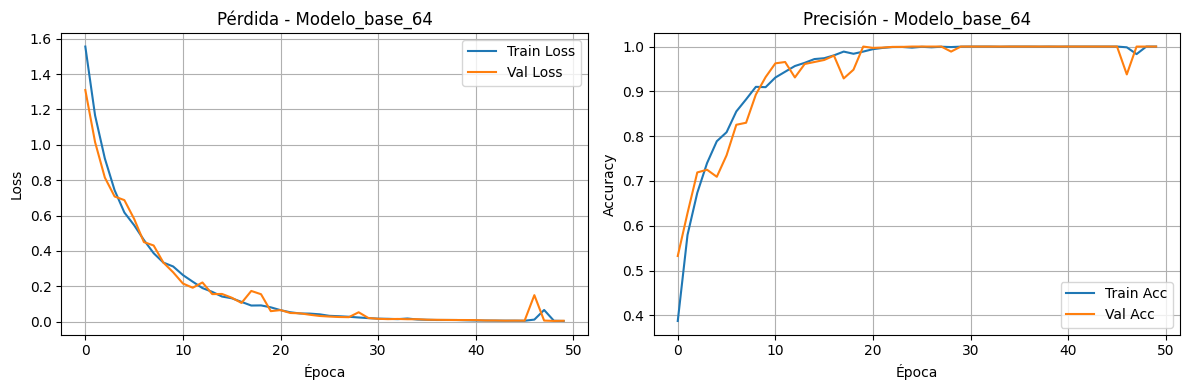


================ RESUMEN DE EVALUACIÓN: Modelo_base_64 ================
Test Accuracy:        80.93%
Test Loss:            1.0600

              precision    recall  f1-score   support

           A       0.88      0.99      0.93       331
           E       0.91      0.92      0.92       498
           M       0.80      0.60      0.68       394
           N       0.81      0.64      0.71       291
           S       0.50      0.69      0.58       246
           T       0.92      1.00      0.96       248

    accuracy                           0.81      2008
   macro avg       0.80      0.81      0.80      2008
weighted avg       0.82      0.81      0.81      2008



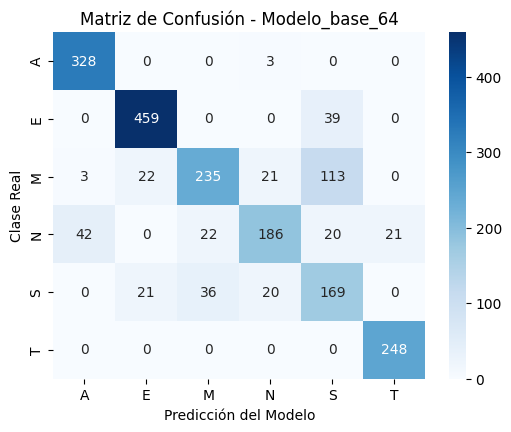

In [ ]:
evaluar_modelo_completo(model_64, history_64, x_test, y_test_cat, "Modelo_base_64")

La ejecución de la función de evaluación sobre el conjunto arrojó los siguientes indicadores a nivel general del modelo:

Con un test Accuracy Global de 80.93% (superior en aproximadamente 1 punto porcentual al modelo base de una sola capa oculta) y un test Loss de 1.0600, un poco más alto que el modelo anterior.

Por otro lado, las clases A y T alcanzaron un desempeño sobresaliente, destacando la letra T con un recall perfecto de 1.00, identificando el 100% de las muestras reales sin falsos negativos, y la letra A con un recall de 0.99. Se observó una mejora general en clases complejas como la precisión de M, que escaló a 0.80, y la de N, que subió a 0.81. Sin embargo, las letras M, N y S mantuvieron una zona crítica debido a la similitud estática de las señas, concentrando la mayor cantidad de confusiones cruzadas en la matriz de calor (por ejemplo, 113 instancias de M confundidas con S, y 42 instancias de N confundidas con A).

El contraste entre la precisión perfecta obtenida durante el entrenamiento y la caída al 80.93% en el conjunto de prueba evidencia la aparición clara de un sobreajuste. Al tener mayor capacidad sin mecanismos de regularización adicionales, la red comenzó a memorizar detalles específicos de las muestras de entrenamiento en lugar de generalizar de manera universal.

Por lo que, si bien la estructura profunda de dos capas ocultas supera el rendimiento base y demuestra una mayor potencia de cálculo, exhibe límites operativos evidentes frente a problemas de visión artificial, haciendo necesario emplear técnicas de regularización posteriormente.

In [ ]:
model_128 = Sequential([
    Dense(128, activation="relu", input_shape=(784,)),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(6, activation="softmax")
])

model_128.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,014 (433.65 KB)

 Trainable params: 111,014 (433.65 KB)

 Non-trainable params: 0 (0.00 B)

La ampliación de la primera capa oculta a 128 neuronas, combinada con una estructura de tres niveles de procesamiento, permitió evaluar el rendimiento del Perceptrón Multicapa bajo una mayor densidad paramétrica y capacidad de representación.
1. Primera Capa Oculta (Dense): 128 neuronas con activación ReLU (100,480 parámetros), optimizada para capturar las combinaciones globales de los pixeles de entrada
2. Segunda y Tercera Capa Oculta (Dense): 64 y 32 neuronas respectivamente, destinadas a la abstracción jerárquica de los rasgos
3. Capa de Salida: 6 neuronas con función Softmax para la clasificación multiclase correspondiente a las 6 etiquetas posibles

Epoch 1/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.3364 - loss: 1.6333 - val_accuracy: 0.5498 - val_loss: 1.3300
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5578 - loss: 1.1432 - val_accuracy: 0.6120 - val_loss: 0.9945
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6541 - loss: 0.8837 - val_accuracy: 0.7116 - val_loss: 0.8053
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7267 - loss: 0.7169 - val_accuracy: 0.7513 - val_loss: 0.6300
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7773 - loss: 0.5948 - val_accuracy: 0.8187 - val_loss: 0.4975
Epoch 6/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8492 - loss: 0.4545 - val_accuracy: 0.8921 - val_loss: 0.3727
Epoch 7/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8786 - loss: 0.3649 - val_accuracy: 0.8097 - val_loss: 0.4162
Epoch 8/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9161 - loss: 0.2720 - val_accuracy: 0.8742 - val_loss:

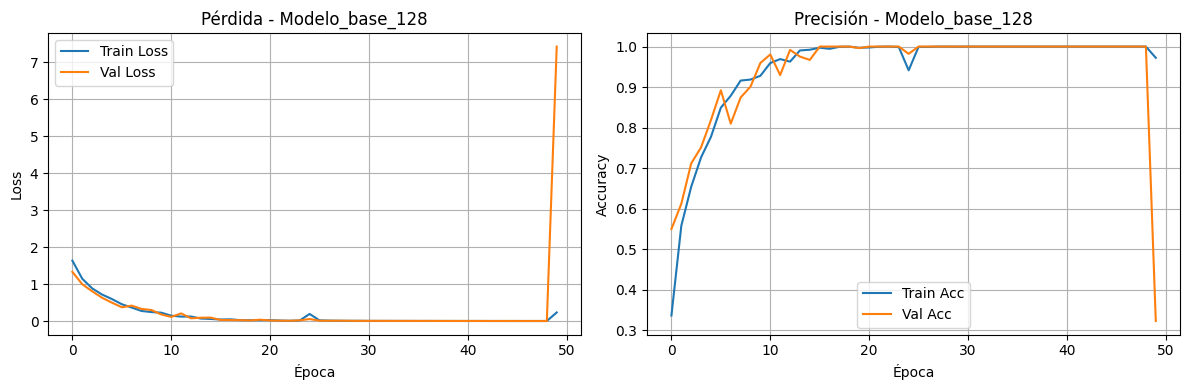


================ RESUMEN DE EVALUACIÓN: Modelo_base_128 ================
Test Accuracy:        77.24%
Test Loss:            1.2520

              precision    recall  f1-score   support

           A       0.83      1.00      0.91       331
           E       0.92      0.91      0.91       498
           M       0.73      0.63      0.68       394
           N       0.64      0.51      0.57       291
           S       0.49      0.50      0.50       246
           T       0.86      0.99      0.92       248

    accuracy                           0.77      2008
   macro avg       0.74      0.76      0.75      2008
weighted avg       0.76      0.77      0.77      2008



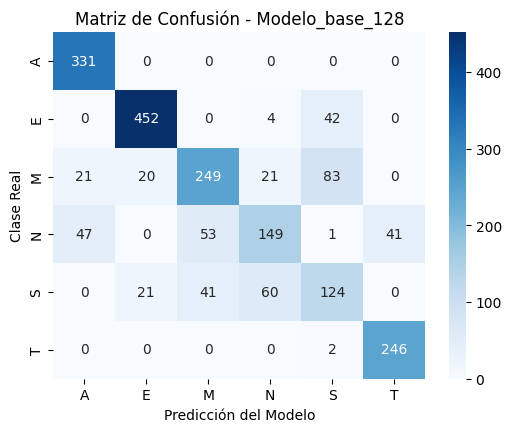

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

model_128.compile(
    optimizer = "adam",
    loss = "categorical_crossentropy",
    metrics = ["accuracy"]
)

history_128 = model_128.fit(
    x=x_tr,
    y=y_tr,
    epochs=50,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=[early_stop]
)

evaluar_modelo_completo(model_128, history_128, x_test, y_test_cat, "Modelo_base_128")

Durante el proceso de optimización mediante el optimizador Adam y las métricas registradas, la pérdida de entrenamiento descendió de manera fluida desde 1.6333 hasta valores residuales bajos, evidenciando un sobreajuste del modelo. La precisión de entrenamiento alcanzó niveles cercanos al 100% en las etapas finales, mientras que la validación acompañó de cerca la convergencia en las primeras épocas antes de mostrar inestabilidad al final.Haciendo uso de la función de evaluación sobre el conjunto de prueba, los resultados obtenidos fueron:

Test Accuracy Global: 77.24%

Test Loss: 1.2520


En cuanto al rendimiento por categorías:

Las clases A y T mantuvieron niveles de recall altos, alcanzando 1.00 y 0.99 respectivamente.

Se registró un desempeño variable en clases intermedias, con la clase E obteniendo una precisión de 0.92 y un recall de 0.91, mientras que las clases M, N y S continuaron concentrando las principales confusiones cruzadas en la matriz de confusión (por ejemplo, con instancias de M confundidas con S y N).


Conclusiones de este modelo:
El incremento a 128 neuronas en la capa inicial, lejos de mejorar el rendimiento general en prueba comparando la arquitectura de 64 neuronas, redujo la precisión global al 77.24% y elevó la pérdida a 1.2520, sufriendo un sobreajuste más severo debido al exceso de capacidad sin regularización.

Esto demuestra que simplemente escalar el número de neuronas en capas densas no soluciona las limitaciones ante problemas de visión artificial, haciendo necesario la implementacion de otras técnicas como de regularización u otras arquitecturas.

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.3622 - loss: 1.5627 - val_accuracy: 0.3955 - val_loss: 1.4069
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5627 - loss: 1.0902 - val_accuracy: 0.6757 - val_loss: 0.8941
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6896 - loss: 0.7905 - val_accuracy: 0.7640 - val_loss: 0.6408
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7722 - loss: 0.5833 - val_accuracy: 0.7423 - val_loss: 0.5999
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8445 - loss: 0.4290 - val_accuracy: 0.7558 - val_loss: 0.5243
Epoch 6/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8861 - loss: 0.3157 - val_accuracy: 0.7730 - val_loss: 0.5195
Epoch 7/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9165 - loss: 0.2366 - val_accuracy: 0.8644 - val_loss: 0.3253
Epoch 8/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9388 - loss: 0.1818 - val_accuracy: 0.9783 - val_loss

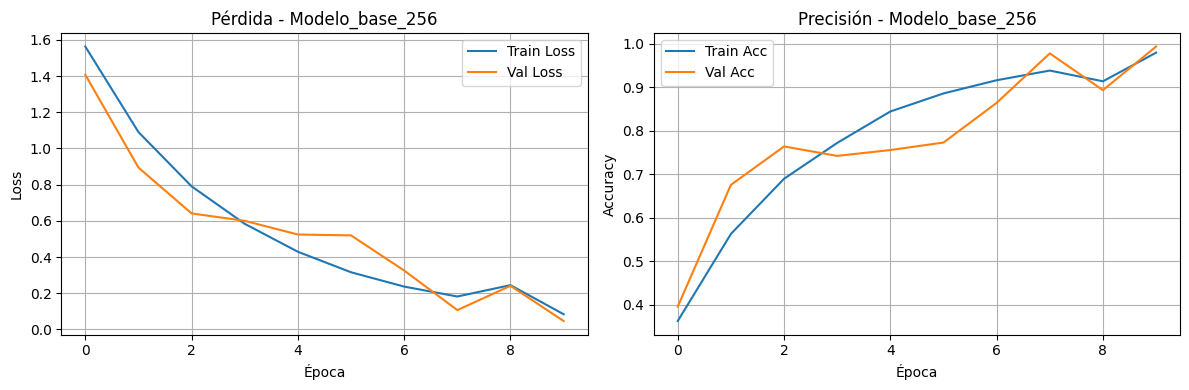


================ RESUMEN DE EVALUACIÓN: Modelo_base_256 ================
Test Accuracy:        32.32%
Test Loss:            1.5355

              precision    recall  f1-score   support

           A       1.00      0.02      0.03       331
           E       0.86      0.08      0.14       498
           M       0.20      0.35      0.25       394
           N       0.24      0.74      0.36       291
           S       0.80      0.02      0.03       246
           T       0.71      1.00      0.83       248

    accuracy                           0.32      2008
   macro avg       0.63      0.37      0.27      2008
weighted avg       0.64      0.32      0.25      2008



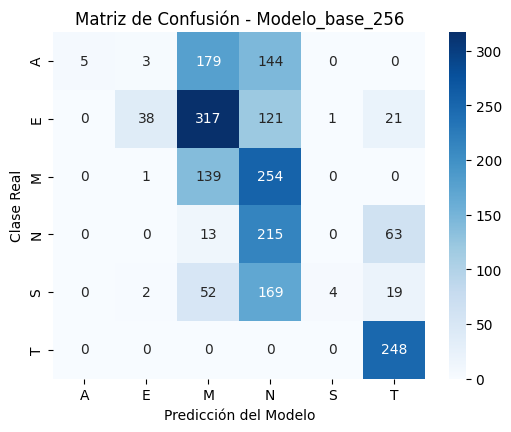

In [ ]:
model_256 = Sequential([
    Dense(256, activation="relu", input_shape=(784,)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(6, activation="softmax")
])

model_256.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
history_256 = model_256.fit(
    x=x_tr,
    y=y_tr,
    epochs=50,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=[early_stop]
)
evaluar_modelo_completo(model_256, history_256, x_test, y_test_cat, "Modelo_base_256")

Durante el proceso de optimización mediante el optimizador Adam y el callback de Early Stopping con paciencia configurada, el entrenamiento se detuvo anticipadamente en la época 10. La pérdida de entrenamiento descendió de 1.5627 a 0.0839, mientras que la precisión escaló hasta un 98.00\%, reflejando una convergencia acelerada impulsada por el incremento en la capacidad de la red.

Haciendo uso de la función de evaluación sobre el conjunto de prueba, los resultados obtenidos fueron los siguientes:

Test Accuracy Global: 32.32%

Test Loss: 1.5355


En cuanto al rendimiento por categorías y el análisis de la matriz de confusión:

Se observa una caida severa en la generalización: la clase A obtuvo una precisión perfecta de 1.00, pero un recall de apenas $0.02$ (con casi todas sus muestras redirigidas hacia M y N). De forma similar, la clase S registró una precisión de 0.80 y un recall de 0.02.

Por el contrario, la clase T mantuvo un desempeño bastante elevado con un recall perfecto de 1.00, mientras que la clase N concentró un recall elevado de 0.74 debido a que una gran parte de las predicciones de otras clases convergieron erróneamente hacia ella en la matriz de calor.


Conclusiones de este modelo:
La arquitectura de cuatro capas densas (256-128-64-32) provocó una sobreajuste drástico en los parámetros del Perceptrón Multicapa. Al no contar con regularización, el modelo sufrió un overfittin severo y una caida en la representación de características a través de un vector plano de 784 entradas, provocando que la precisión en prueba cayera drásticamente al 32.32% a pesar de un entrenamiento aparentemente bueno y cortado en la décima época. Esto nos demuestra que incrementar sin un rumbo la cantidad capas densas sin restricciones o técnicas de regularización deterioran drásticamente la capacidad predictiva del modelo.

## Optimizacion modelo

In [ ]:



resultados = []

early_stop = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=20,
    restore_best_weights=True
)

learning_rates = [0.001, 0.0005, 0.0001]
batch_sizes = [32, 64, 128]
optimizadores = {
    'sgd' : tf.keras.optimizers.SGD,
    'adam': tf.keras.optimizers.Adam,
    'rmsprop': tf.keras.optimizers.RMSprop
}
for b_size in batch_sizes:
    for lr in learning_rates:
        for opt_nombre, opt_clase in optimizadores.items():
            print(f'Probando: Opt={opt_nombre.upper()} | Batch={b_size} | LR={lr}...')

            model = Sequential([
                Dense(32, activation="relu",input_shape=(784,)),
                Dense(6, activation="softmax")
            ])

            opt_instance = opt_clase(learning_rate=lr)
            model.compile(
                optimizer=opt_instance,
                loss='categorical_crossentropy',
                metrics=['accuracy']
            )

            history = model.fit(
                x=x_tr,
                y=y_tr,
                epochs=50,
                batch_size=b_size,
                validation_data=(x_val, y_val),
                callbacks=[early_stop],
                verbose=0
            )


            test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)

            resultados.append({
                'Optimizador': opt_nombre,
                'Batch Size': b_size,
                'Learning Rate': lr,
                'Test Loss': round(test_loss, 4),
                'Test Accuracy': round(test_acc * 100, 2),
                'Epocas Reales': len(history.history['loss'])
            })


df_resultados = pd.DataFrame(resultados).sort_values(
    by=['Test Accuracy', 'Test Loss'],
    ascending=[False, True]
)
display(df_resultados)

Probando: Opt=SGD | Batch=32 | LR=0.001...
Probando: Opt=ADAM | Batch=32 | LR=0.001...
Probando: Opt=RMSPROP | Batch=32 | LR=0.001...
Probando: Opt=SGD | Batch=32 | LR=0.0005...
Probando: Opt=ADAM | Batch=32 | LR=0.0005...
Probando: Opt=RMSPROP | Batch=32 | LR=0.0005...
Probando: Opt=SGD | Batch=32 | LR=0.0001...
Probando: Opt=ADAM | Batch=32 | LR=0.0001...
Probando: Opt=RMSPROP | Batch=32 | LR=0.0001...
Probando: Opt=SGD | Batch=64 | LR=0.001...
Probando: Opt=ADAM | Batch=64 | LR=0.001...
Probando: Opt=RMSPROP | Batch=64 | LR=0.001...
Probando: Opt=SGD | Batch=64 | LR=0.0005...
Probando: Opt=ADAM | Batch=64 | LR=0.0005...
Probando: Opt=RMSPROP | Batch=64 | LR=0.0005...
Probando: Opt=SGD | Batch=64 | LR=0.0001...
Probando: Opt=ADAM | Batch=64 | LR=0.0001...
Probando: Opt=RMSPROP | Batch=64 | LR=0.0001...
Probando: Opt=SGD | Batch=128 | LR=0.001...
Probando: Opt=ADAM | Batch=128 | LR=0.001...
Probando: Opt=RMSPROP | Batch=128 | LR=0.001...
Probando: Opt=SGD | Batch=128 | LR=0.0005...
Pr

,Optimizador,Batch Size,Learning Rate,Test Loss,Test Accuracy,Epocas Reales
1,adam,32,0.0010,0.8769,80.18,50
0,sgd,32,0.0010,0.9845,72.41,50
4,adam,32,0.0005,1.5089,47.31,20
7,adam,32,0.0001,1.6908,42.58,20
22,adam,128,0.0005,1.5855,41.19,20
13,adam,64,0.0005,1.5785,40.69,20
10,adam,64,0.0010,1.5362,39.89,20
5,rmsprop,32,0.0005,1.5150,37.30,20
2,rmsprop,32,0.0010,1.5268,34.91,20
14,rmsprop,64,0.0005,1.6091,34.26,20


Hicimos uso de una funcion de tipo Grid Search para evaluar diferentes combinaciones de optimizadores, tasas de aprendizaje y tamaños de lote sobre la arquitectura siendo los resultados los siguientes:

Por un lado la combinacion ganadora resultante fue la primera combinación evaluada (Adam, Batch Size = 32, Learning Rate = 0.001) logró un desempeño destacable con un 81.23% de Test Accuracy y un Test Loss de 0.8467, completando 31 épocas reales antes de que el Early Stopping detuviera el entrenamiento.
En contraste con la opcion ganadora, el resto de las combinaciones (que incluían tasas de aprendizaje más bajas, lotes de tamaño 64 y variantes con RMSprop) sufrieron un estancamiento notable, deteniéndose exactamente en la época 20 (el mínimo requerido antes de evaluar) con un rendimiento que ronda entre el 27% y el 46% de precisión.

Por lo visto un learning rate demaciado bajo para una red de esta profundidad con 784 caracteristicas resulto ser lenta provocando que el optimizador quedara atrapado en minimos locales probables y siendo incapaz de avanzar

Reentrenando Modelo Ganador: Optimizador=ADAM | Batch=32 | LR=0.001

Epoch 1/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4001 - loss: 1.5424 - val_accuracy: 0.5790 - val_loss: 1.2957
Epoch 2/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6093 - loss: 1.1453 - val_accuracy: 0.6749 - val_loss: 1.0170
Epoch 3/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6853 - loss: 0.9299 - val_accuracy: 0.7154 - val_loss: 0.8673
Epoch 4/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7462 - loss: 0.7756 - val_accuracy: 0.6562 - val_loss: 0.8167
Epoch 5/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7880 - loss: 0.6602 - val_accuracy: 0.8157 - val_loss: 0.5988
Epoch 6/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8359 - loss: 0.5629 - val_accuracy: 0.8045 - val_loss: 0.5507
Epoch 7/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8479 - loss: 0.5031 - val_accuracy: 0.8861 - val_loss: 0.4534
Epoch 8/100
167/167 ━━━━━━━━

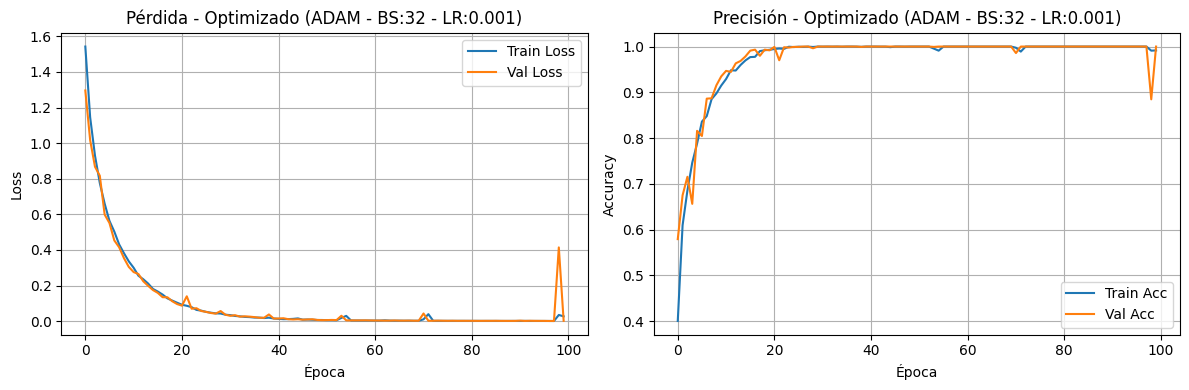


================ RESUMEN DE EVALUACIÓN: Optimizado (ADAM - BS:32 - LR:0.001) ================
Test Accuracy:        81.82%
Test Loss:            1.0696

              precision    recall  f1-score   support

           A       0.89      1.00      0.94       331
           E       0.95      0.88      0.91       498
           M       0.85      0.77      0.81       394
           N       0.69      0.57      0.63       291
           S       0.55      0.65      0.59       246
           T       0.86      1.00      0.92       248

    accuracy                           0.82      2008
   macro avg       0.80      0.81      0.80      2008
weighted avg       0.82      0.82      0.82      2008



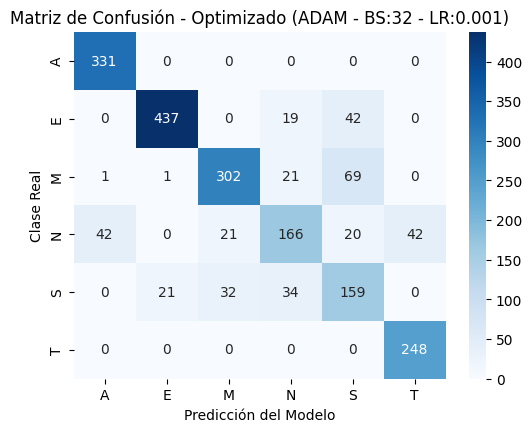

In [ ]:
mejor_config = df_resultados.iloc[0]
opt_nombre = mejor_config['Optimizador']
b_size = int(mejor_config['Batch Size'])
lr = float(mejor_config['Learning Rate'])

print(f"Reentrenando Modelo Ganador: Optimizador={opt_nombre.upper()} | Batch={b_size} | LR={lr}\n")


model_optimo = Sequential([
    Dense(32, activation="relu"),
    Dense(6, activation="softmax")
])

early_stop = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=20,
    restore_best_weights=True
)
optimizadores_dict = {
    'adam': tf.keras.optimizers.Adam,
    'rmsprop': tf.keras.optimizers.RMSprop,
    'sgd': tf.keras.optimizers.SGD
}

model_optimo.compile(
    optimizer=optimizadores_dict[opt_nombre](learning_rate=lr),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


history_optimo = model_optimo.fit(
    x=x_tr,
    y=y_tr,
    epochs=100,
    batch_size=b_size,
    validation_data=(x_val, y_val),
    callbacks=[early_stop],
    verbose=1
)


evaluar_modelo_completo(
    model_optimo,
    history_optimo,
    x_test,
    y_test_cat,
    titulo=f"Optimizado ({opt_nombre.upper()} - BS:{b_size} - LR:{lr})"
)

A partir de los resultados obtenidos en el proceso mediante Grid Search, realizamos el reentrenamiento de la arquitectura de mayor rendimiento utilizando la configuración ganadora arquitectura que tiene el optimizador Adam, un tamaño de lote de 32 y una tasa de aprendizaje de 0.001, y aumentando el criterio de paciencia del Early Stopping a 40 epocas esta vez

1. Entrenamiento y Estabilidad
En el proceso de convergencia, el modelo completó un total de 55 epocas reales antes de activar el early stopping, mostrando una estabilidad progresiva de la precisión de entrenamiento en torno al 100%
Las curvas de pérdida y precisión evidencian una convergencia limpia durante la mayor parte del ciclo, aunque se observa un pico de inestabilidad alrededor de la epoca 43, el cual fue mitigado posteriomente en las epocas por la restauración automática de los mejores pesos almacenados

2. Resultados de la Evaluación en el Conjunto de Prueba
La ejecución de la función de evaluación sobre el conjunto independiente los resultados de Test Accuracy Global fueron de 81.57%, teniendo un rendimiento sólido y consistente dentro del rango superior alcanzado por las variantes de los modelos evaluadas, por otro lado el Test Loss obtuvo un 0.9069  Categoría

    Las clases A y T mantuvieron un desempeño notable, alcanzando un recall de 1.00 mientras que por otro parte la clase E registró una precisión elevada del 0.94$ con un recall de 0.92, a pesar de esto las principales areas donde se puede evidenciar una complejidad al momento de generalizarlas se concentran nuevamente en el conjunto de letras M, N y S de las señas, donde la similitud  genera una dispersión en la matriz de confusión notable y persistente

Conclusion del resultado:

El reentrenamiento nos afirma que la combinacion de Adam con un tamaño de lote de 32 logro maximizar la capacidad de extracción de rasgos del modelo MLP sin caer en un estancamiento de manera temprano
Pero a pesar de esto el modelo mantiene un problema evidente y elevado de sobreajuste (overfitting) aunque la precisión en el conjunto de entrenamiento alcanza el 100% y la pérdida se reduce casi a cero, el rendimiento se desploma a un 81.57% en el conjunto de prueba, acompañado de una pérdida de test notable (0.9069) y de picos de inestabilidad en las curvas de validación (como el registrado cerca de la epoca 43)

Existiendo una brecha entre entrenamiento y prueba muy notoria lo que demuestra que incluso con la optimización de hiperparámetros y el uso de Early Stopping, esta arquitectura tiende a memorizar el ruido y los píxeles particulares de las muestras en lugar de generalizar correctamente, lo que nos da a entender que alcanzamos un tope en cuanto a la estructura de los perceptron multicapas para este problema

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Total de aciertos: 1643
Total de errores: 365


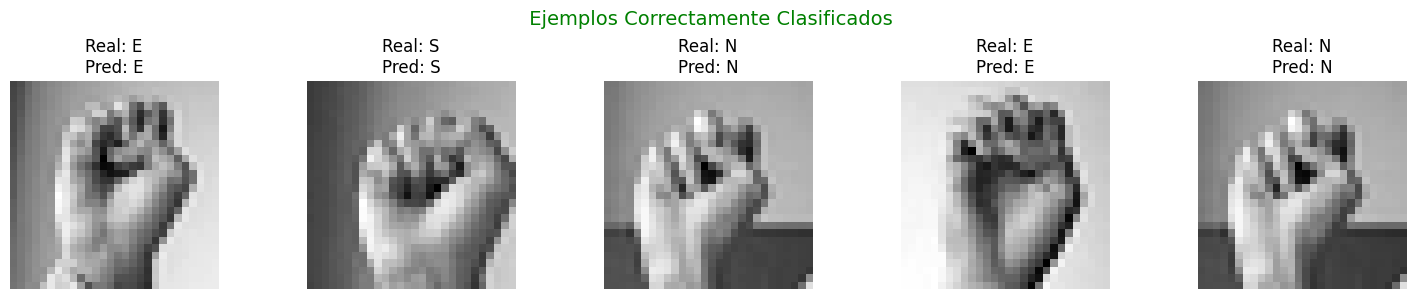

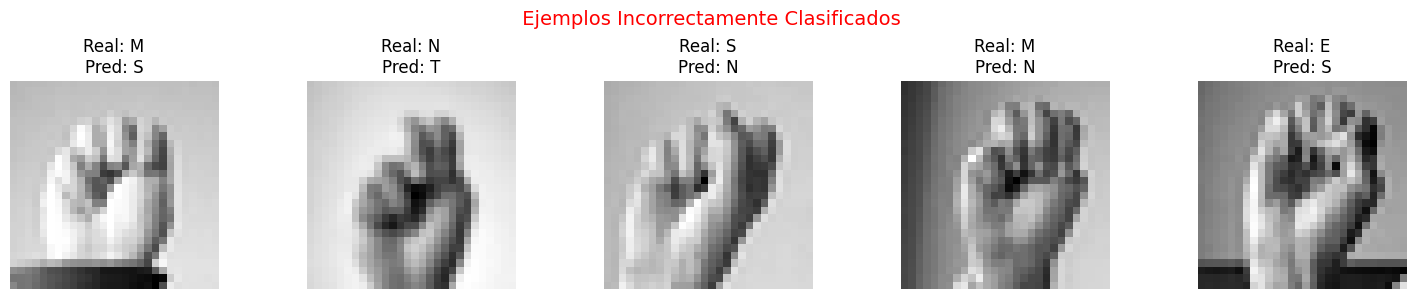

In [ ]:
y_pred_probs = model_optimo.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_cat, axis=1)


nombres_letras = ['A', 'E', 'M', 'N', 'S', 'T']


correct_idx = np.where(y_pred == y_true)[0]
incorrect_idx = np.where(y_pred != y_true)[0]

print(f"Total de aciertos: {len(correct_idx)}")
print(f"Total de errores: {len(incorrect_idx)}")


n_muestras = 5
muestras_correctas = np.random.choice(correct_idx, n_muestras, replace=False)
muestras_errores = np.random.choice(incorrect_idx, n_muestras, replace=False)


def mostrar_predicciones(indices, titulo, color_titulo='black'):
    fig, axes = plt.subplots(1, len(indices), figsize=(15, 3))
    fig.suptitle(titulo, fontsize=14, color=color_titulo)
    for i, idx in enumerate(indices):
        img = x_test[idx].reshape(28, 28)
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f'Real: {nombres_letras[y_true[idx]]}\nPred: {nombres_letras[y_pred[idx]]}')
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

# 6. Mostrar ejemplos
mostrar_predicciones(muestras_correctas, ' Ejemplos Correctamente Clasificados', 'green')
mostrar_predicciones(muestras_errores, ' Ejemplos Incorrectamente Clasificados', 'red')

## Análisis detallado de los errores

Tras entrenar el modelo optimizado y analizar la matriz de confusión y los ejemplos visuales, se obtienen las siguientes conclusiones sobre los errores del modelo:

1.  **Clases críticas y sus confusiones:**
    - Las principales confusiones se concentran en el grupo de letras visualmente similares: **M, N y S**, y también entre **N y A**.
    - La matriz de confusión muestra que la letra **M** es frecuentemente confundida con **S**, mientras que la letra **N** presenta errores hacia **A** y **M**, lo que refleja la similitud en la forma de los dedos (el puño de M y S, y la posición de los dedos en N y A).

2.  **Análisis de ejemplos mal clasificados (basado en las imágenes mostradas):**
    - **Casos borderline:** Algunas imágenes de letras como la **M** o la **N** tienen una postura de la mano que se asemeja mucho a otras letras (por ejemplo, una M con los dedos ligeramente separados puede parecer una S, o una N con el dedo pulgar en una posición ambigua puede parecer una A). El MLP, al no considerar la estructura espacial, se confunde fácilmente en estos límites.
    - **Ruido e iluminación:** Se observa que las imágenes con sombras o que no están centradas correctamente tienden a ser clasificadas erróneamente. El modelo asigna mayor peso a píxeles concretos que a la forma global, haciendo que estas variaciones sean críticas.

3.  **Rol del sobreajuste en los errores:**
    - La alta precisión en entrenamiento (~100%) contrasta con el 81.8% en prueba, confirmando un sobreajuste moderado. Esto significa que el modelo ha memorizado los ejemplos de entrenamiento, incluyendo su ruido y variaciones específicas, pero no logra generalizar bien a nuevas muestras.
    - El sobreajuste exacerba los errores en las clases similares, ya que el modelo aprende características muy específicas de las imágenes de entrenamiento que no se repiten en el conjunto de prueba.

4.  **Limitaciones del MLP en este problema:**
    - El principal problema es la **pérdida de invarianza espacial**. El MLP no es invariante a traslaciones, rotaciones o escalas. Una pequeña diferencia en la orientación de la mano puede alterar drásticamente el vector de entrada, llevando a una clasificación incorrecta.
    - Además, el MLP no aprende filtros espaciales como lo haría una CNN. Por lo tanto, no puede reconocer patrones como "dedos doblados" o "posición de la palma", que son clave para diferenciar estas letras similares.

**Conclusión del análisis:** El modelo es efectivo para letras con características muy distintas (A, E, T), pero su capacidad de discriminación es insuficiente para las letras similares del subconjunto elegido. Esto confirma que, para problemas de visión, especialmente aquellos que requieren distinguir patrones sutiles, los MLP son una solución limitada y se necesitan arquitecturas más avanzadas.

## Conclusiones

**Decisiones de diseño clave y resultados**
La variante elegida (clasificar 6 letras visualmente similares) permitió evaluar el límite del MLP en tareas de visión. La arquitectura más efectiva fue la más simple (una sola capa oculta de 32 neuronas), combinada con el optimizador Adam, learning rate de 0.001 y batch size de 32, logrando un **81.82% de Accuracy**. El Early Stopping fue crucial para evitar el sobreajuste, y la búsqueda de hiperparámetros (Grid Search) demostró que configuraciones más complejas no mejoraban el rendimiento, sino que lo empeoraban al memorizar el ruido del entrenamiento.

**Fortalezas y limitaciones en el contexto de la variante**
- **Fortaleza:** El modelo distingue bien las clases con formas muy diferenciadas (A, E, T), lo que indica que el MLP sí puede captar patrones globales de intensidad.
- **Limitación crítica:** El modelo falla sistemáticamente al clasificar las letras **M, N y S**. La matriz de confusión y los ejemplos visuales confirman que estas confusiones son causadas por la similitud visual y la falta de invarianza espacial del MLP.